In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
cluster_order = pd.read_csv('data/cluster_order_HLCA.csv')
cluster_order = [x[0] for x in cluster_order.values]

In [3]:
# read in data
az = pd.read_csv('data/azimuth_hlca.csv', index_col=0)
ct = pd.read_csv('data/celltypist_hlca.csv', index_col=0)
sc = pd.read_csv('data/scarches_hlca.csv', index_col=0)
fr = pd.read_csv('data/frmatch_hlca.csv', index_col=0)
sr = pd.read_csv('data/singleR_hlca.csv', index_col=0)
sp = pd.read_csv('data/scpred_hlca.csv', index_col=0)

In [4]:
def heatmap(df, title): 
    df2 = df.groupby(['hlca_true', 'hlca_pred'])['score'].mean().reset_index()
    
    piv = df2.pivot(index='hlca_true', columns='hlca_pred', values='score')
    piv = piv.reindex(cluster_order)
    piv = piv.reindex(cluster_order, axis=1).fillna(0)
    
    
    # plot
    plt.figure(figsize=(20, 15))  # Adjust the width and height as needed

    ax = sns.heatmap(piv, vmin=0, vmax=1, cmap=sns.color_palette("rocket_r", as_cmap=True)
    )

    ax.set_xlabel('hlca_pred', fontsize=20)
    ax.set_ylabel('hlca_true', fontsize=20)
    ax.set_xticks(range(piv.shape[1]))
    ax.set_xticklabels(piv.columns, rotation=90, fontsize=15)
    ax.set_yticks(range(piv.shape[0]))
    ax.set_yticklabels(piv.index, fontsize=15)
    plt.title(title, fontsize=35)

    plt.show()
    
    


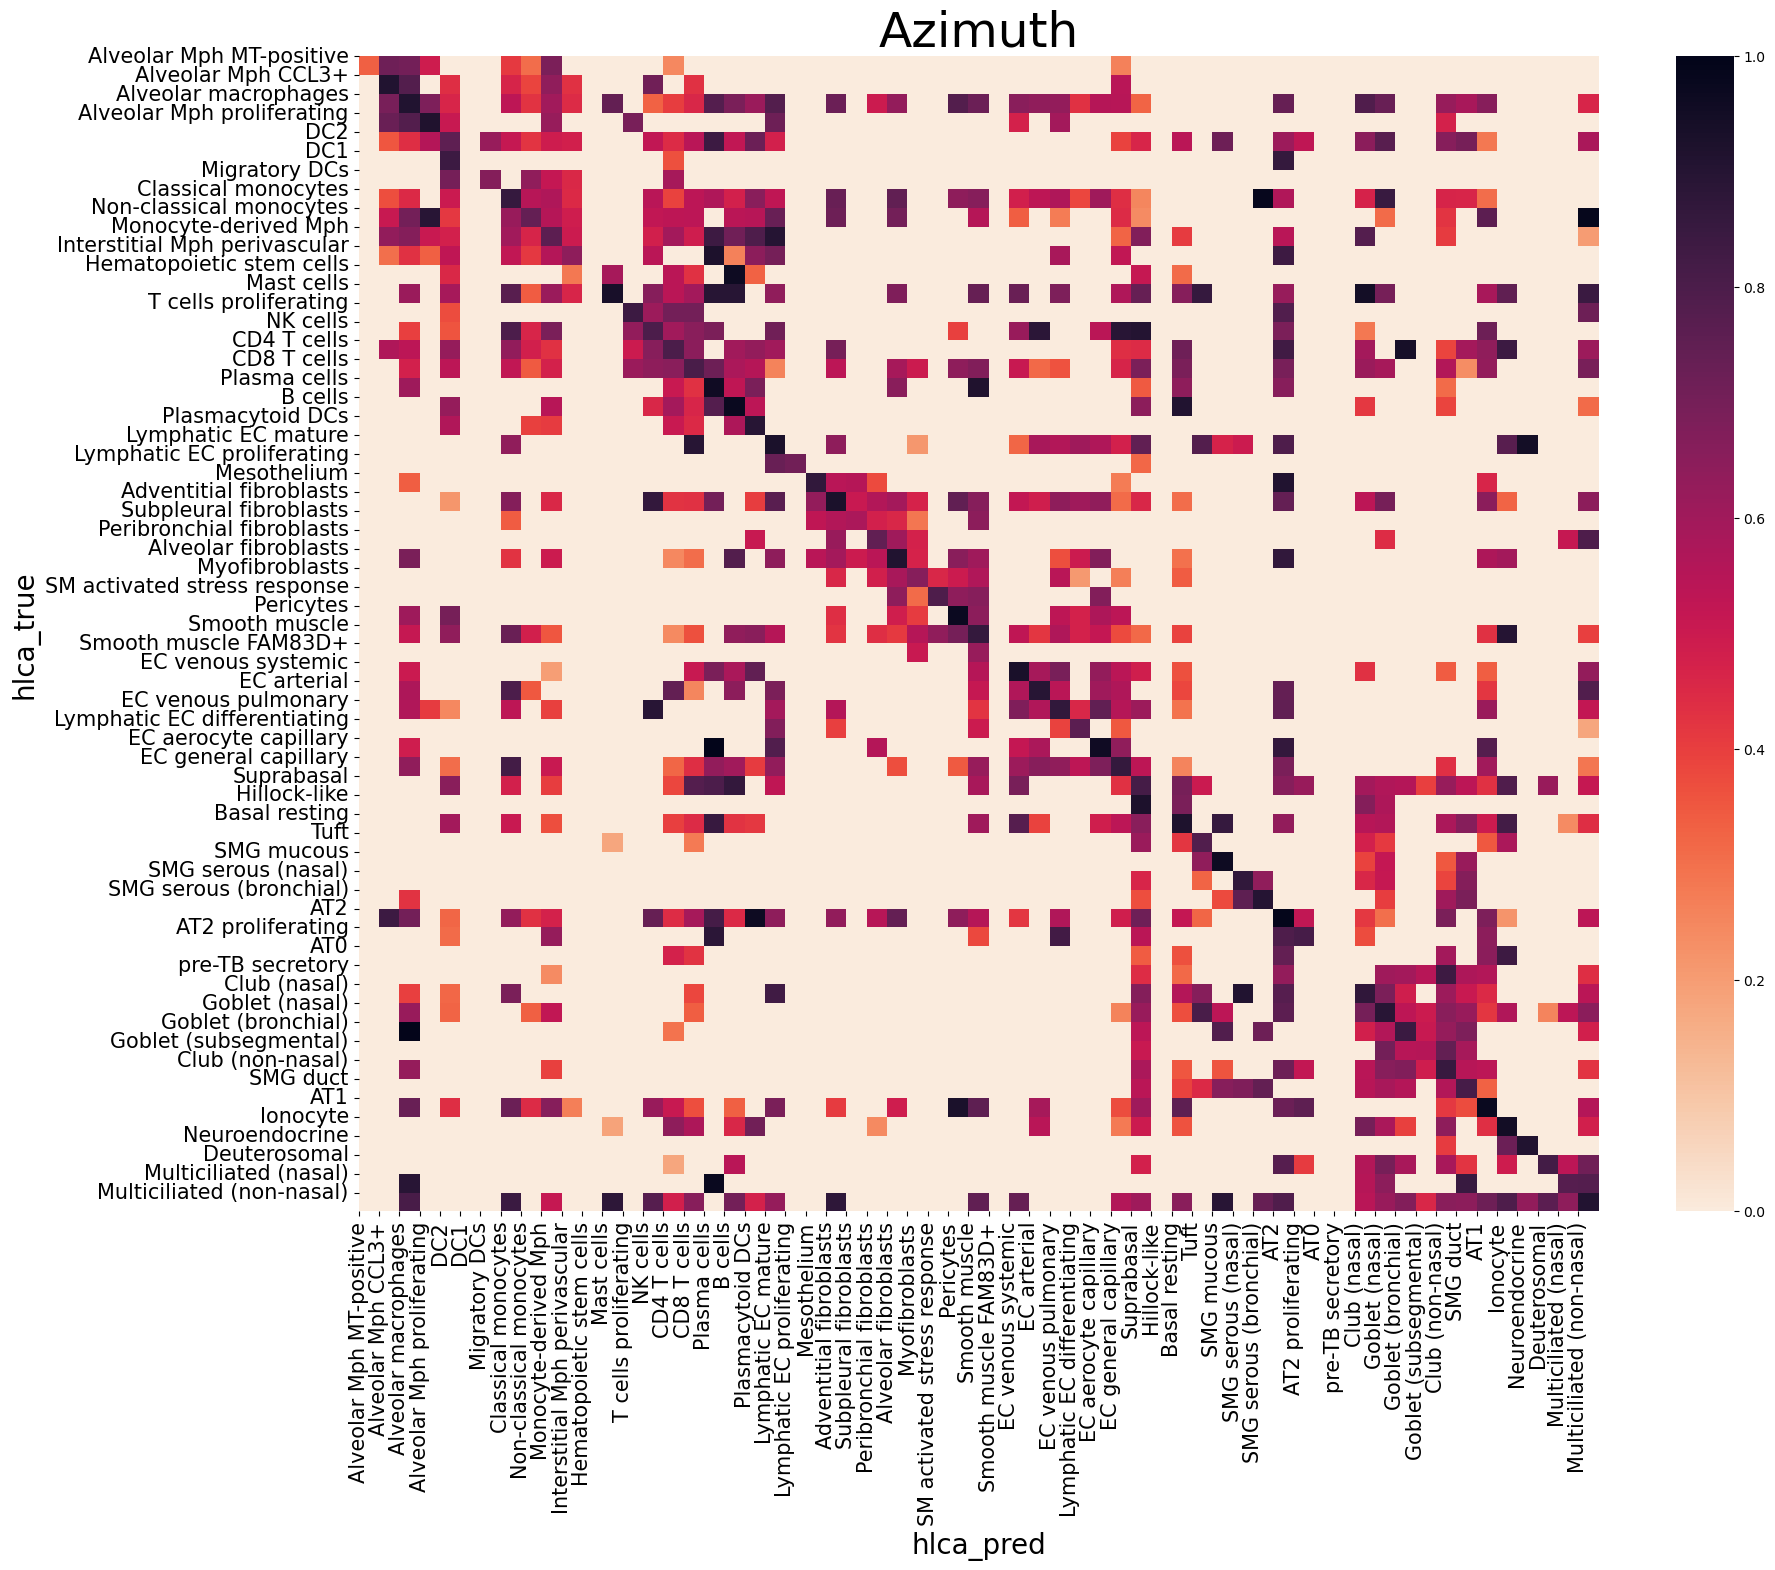

In [5]:
heatmap(az, 'Azimuth')

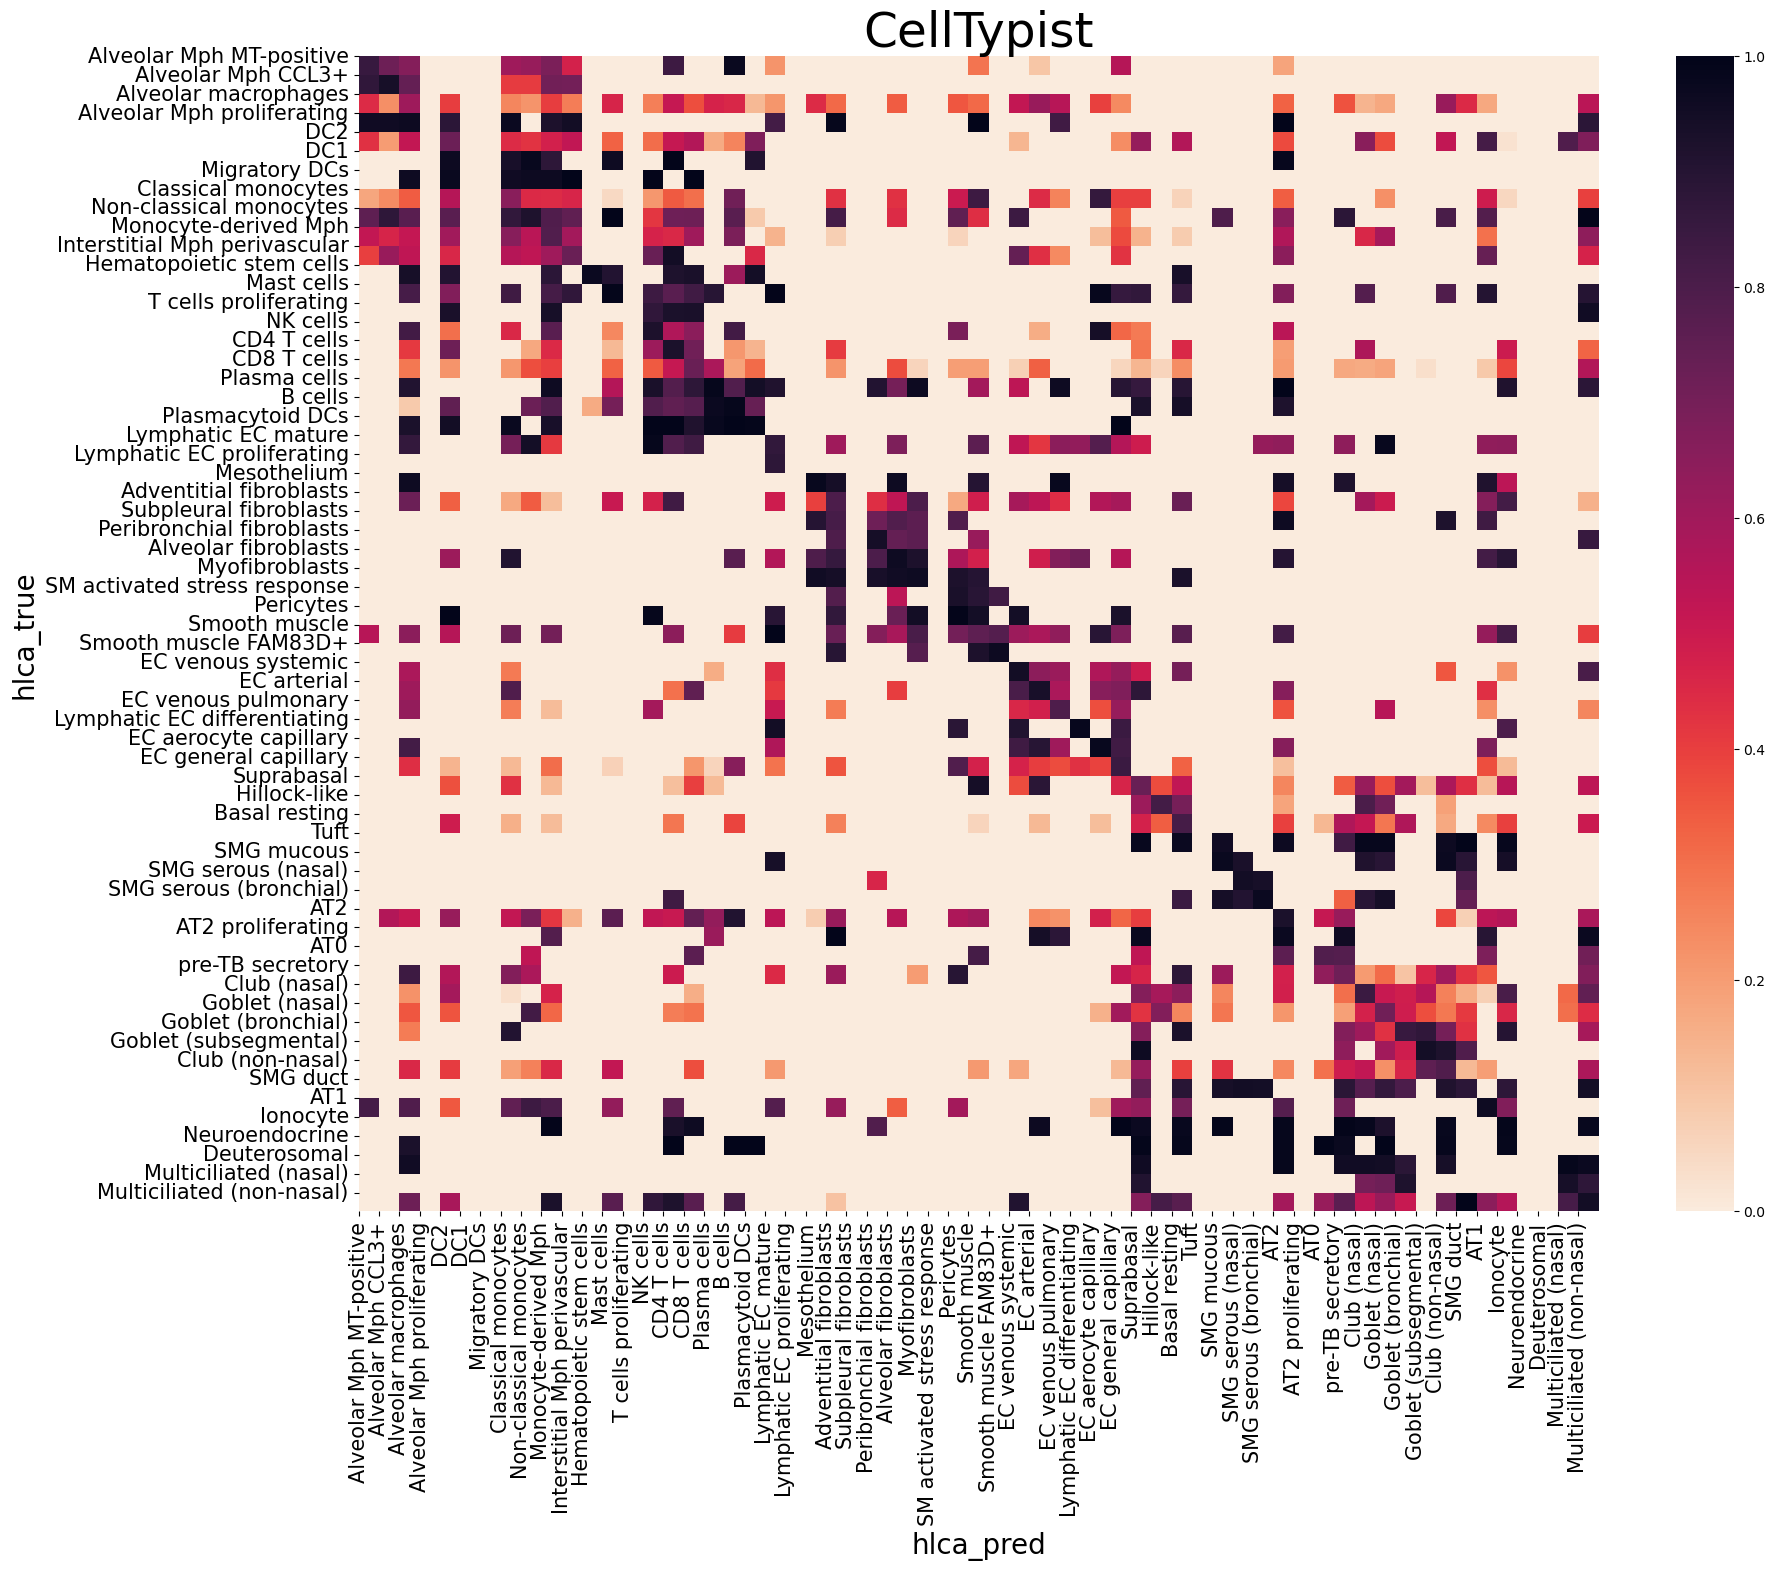

In [6]:
heatmap(ct, 'CellTypist')

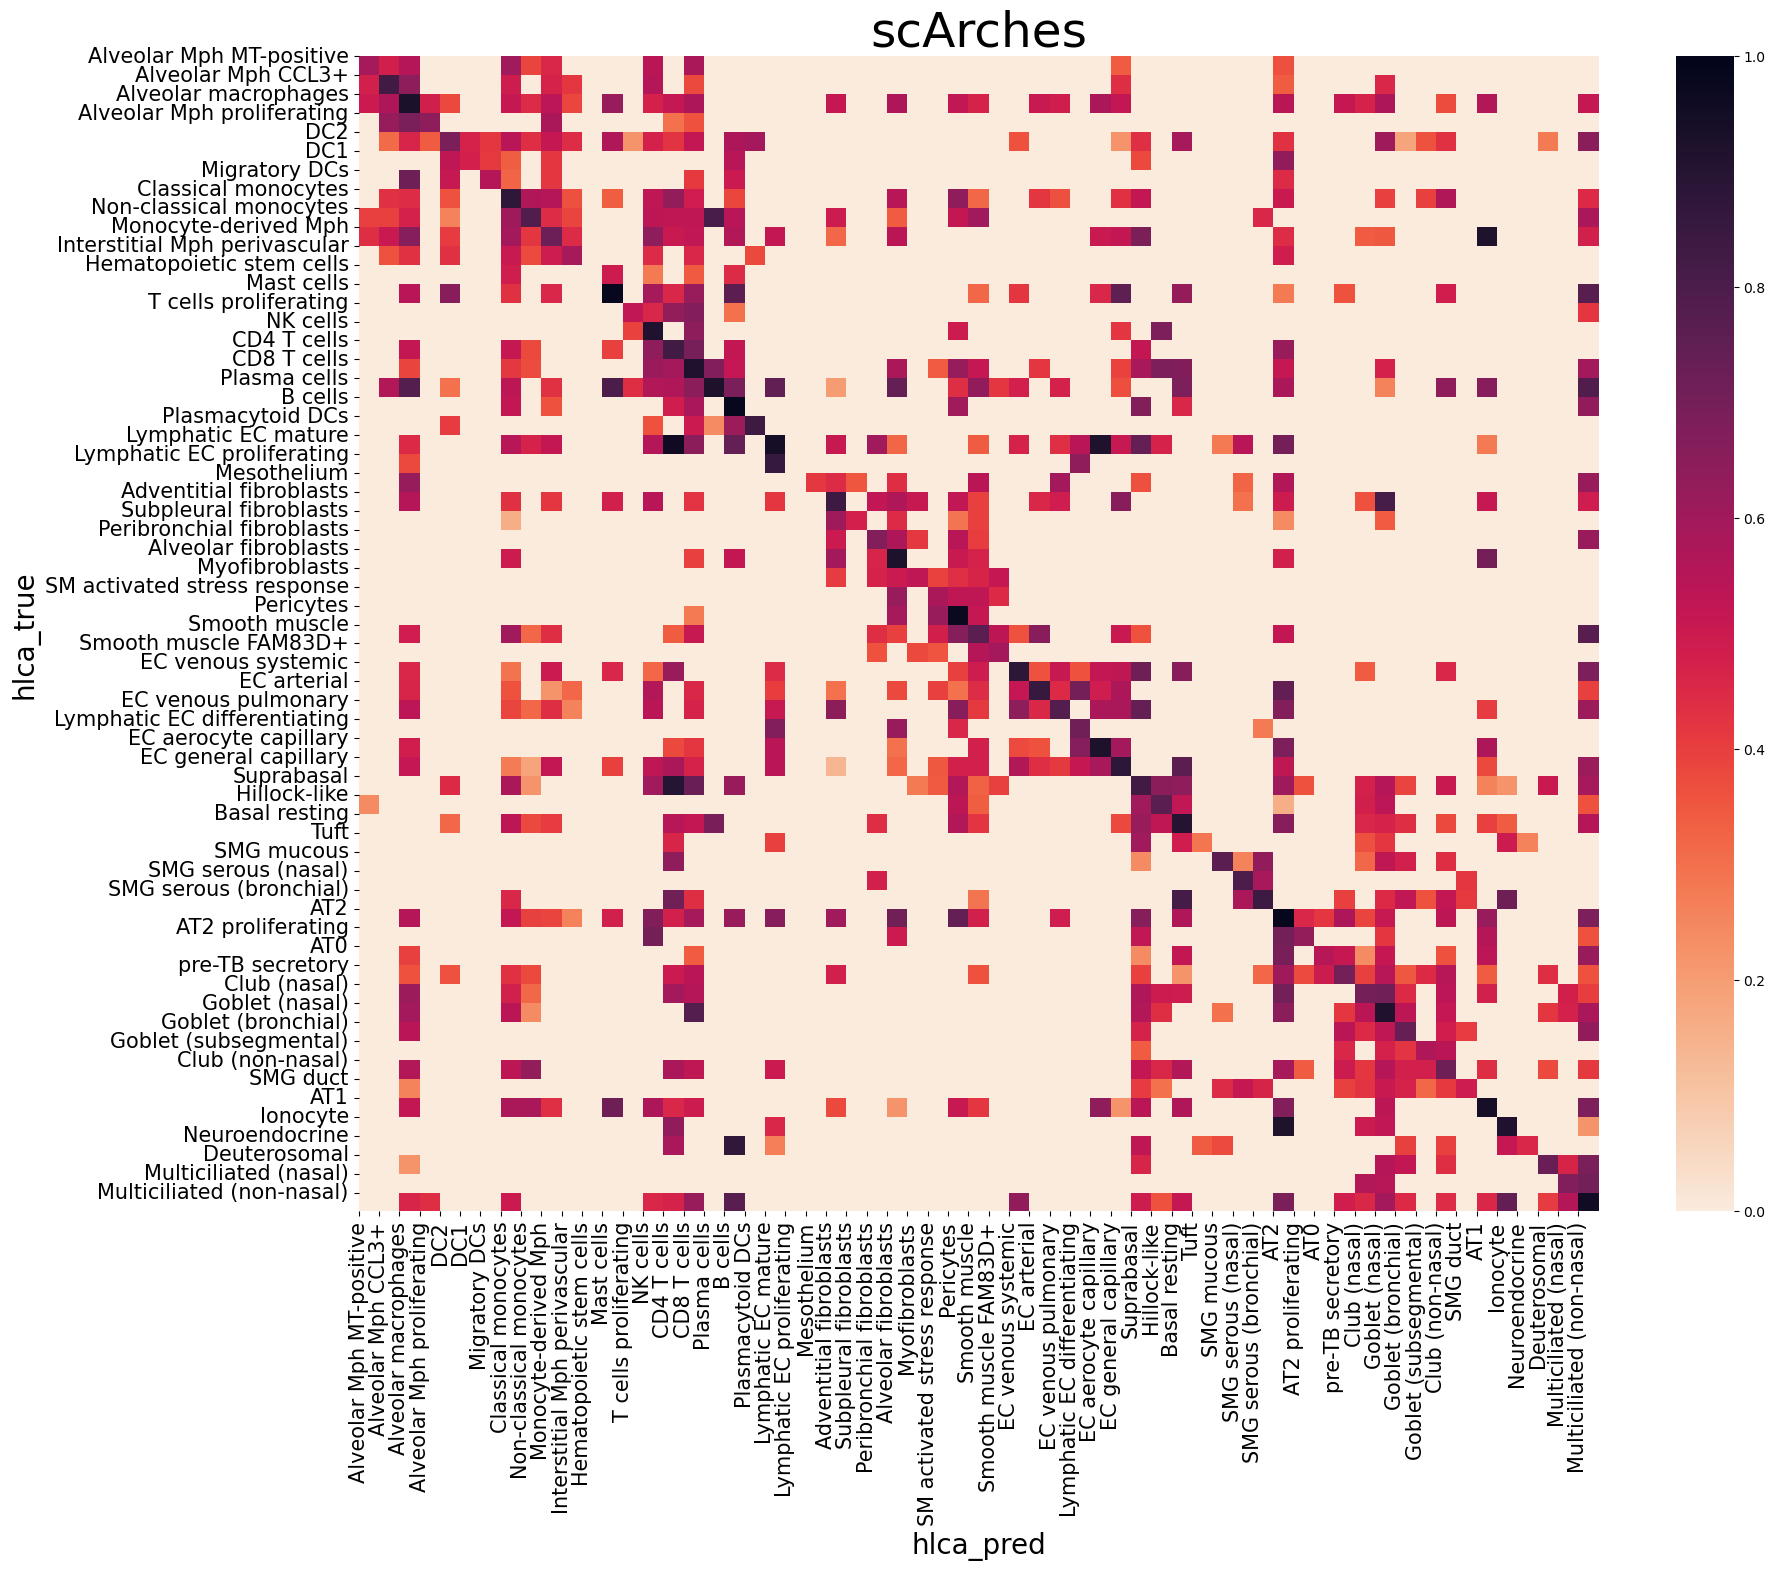

In [7]:
heatmap(sc, 'scArches')

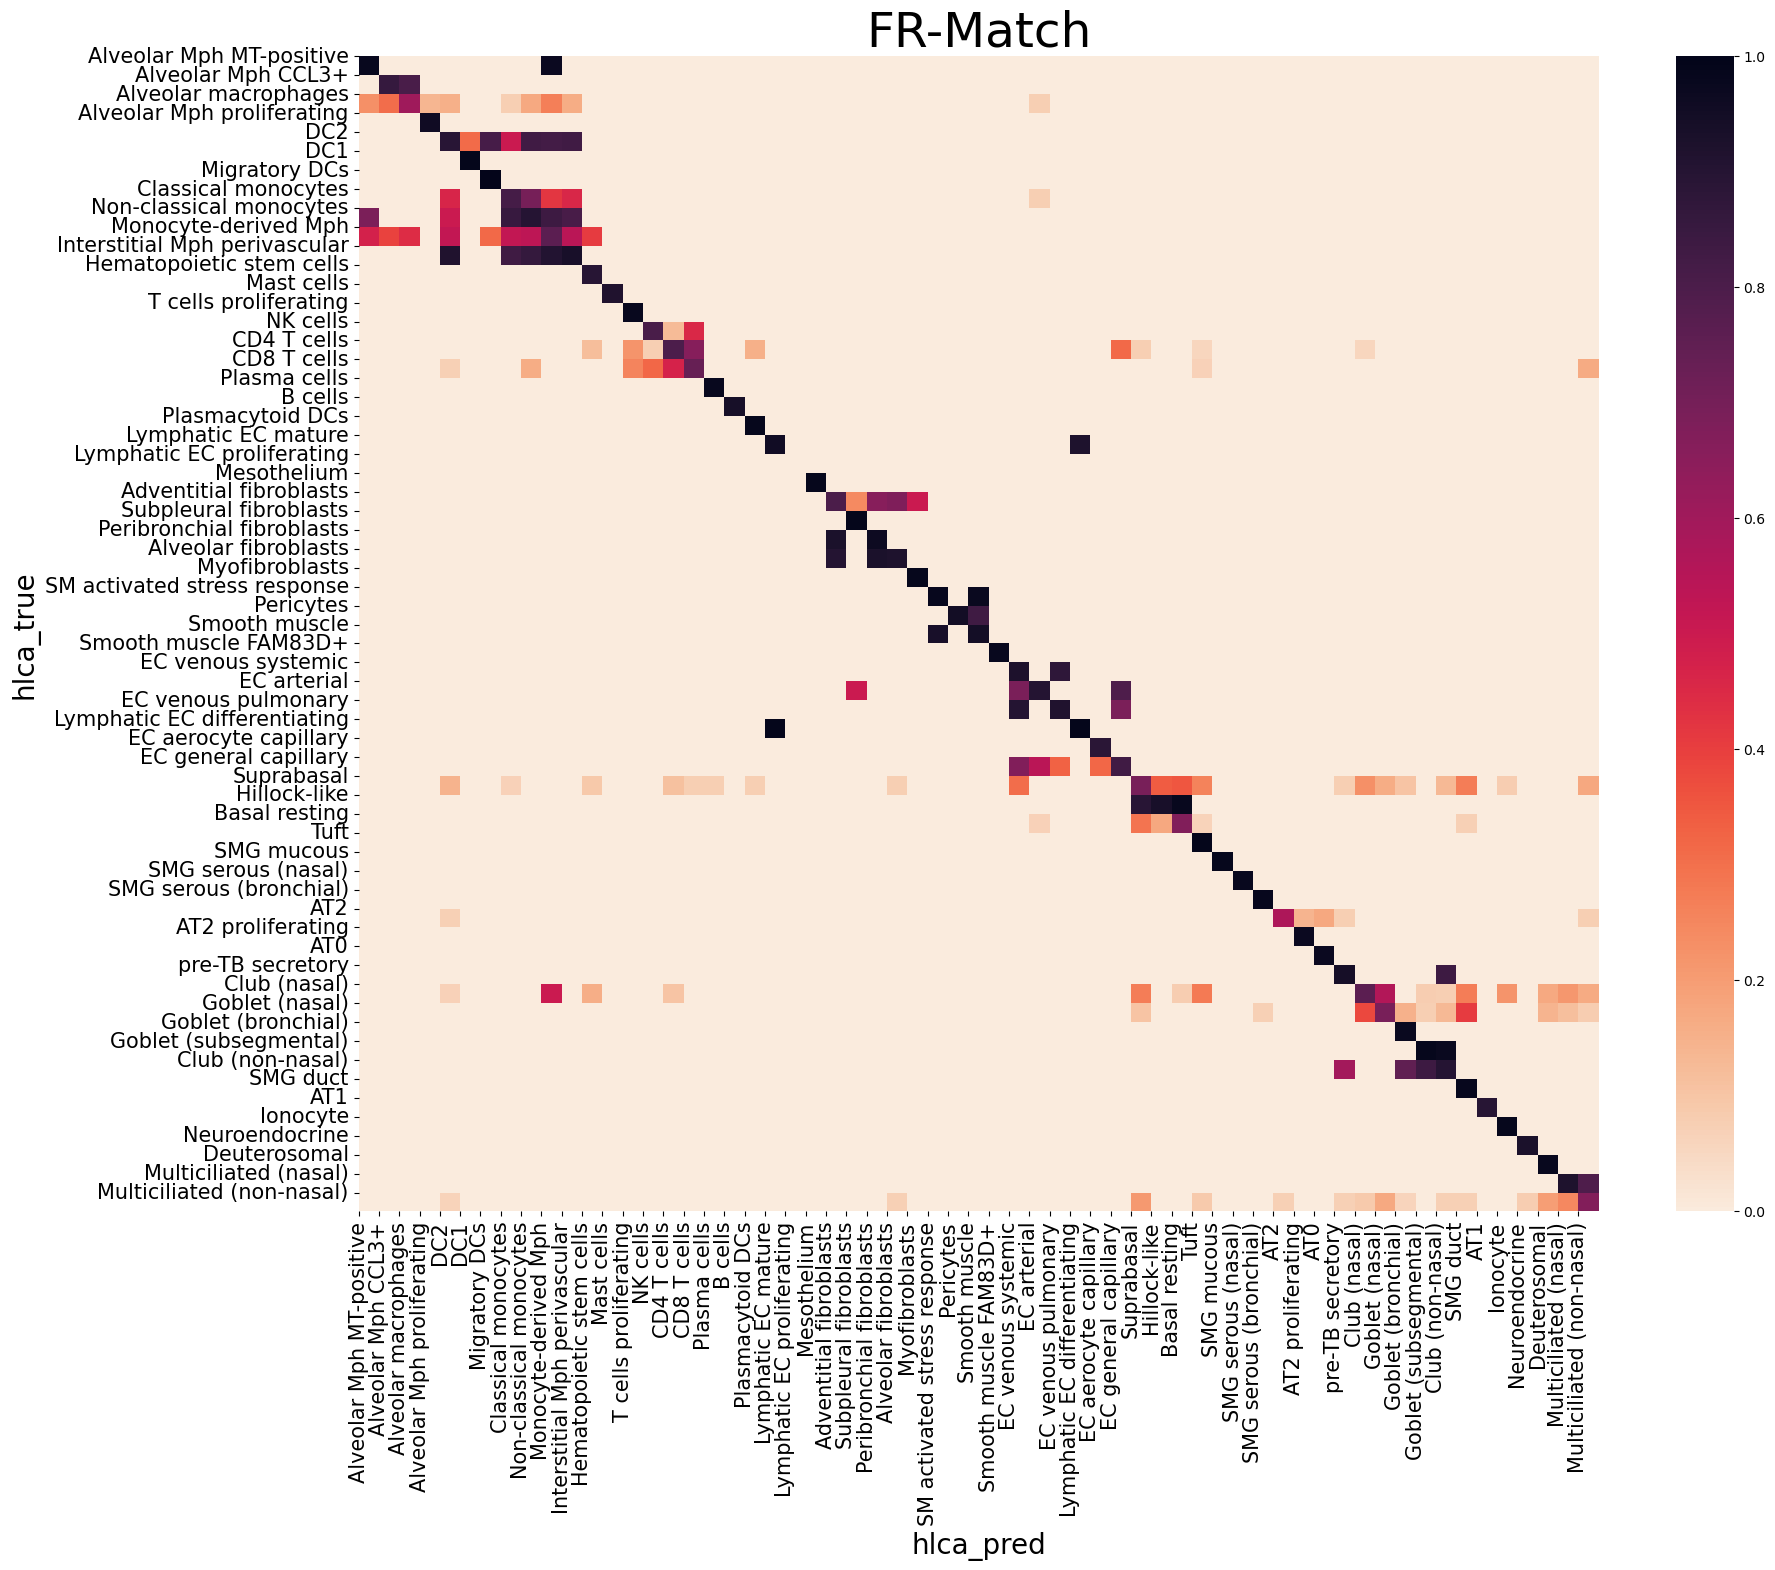

In [8]:
heatmap(fr, 'FR-Match')

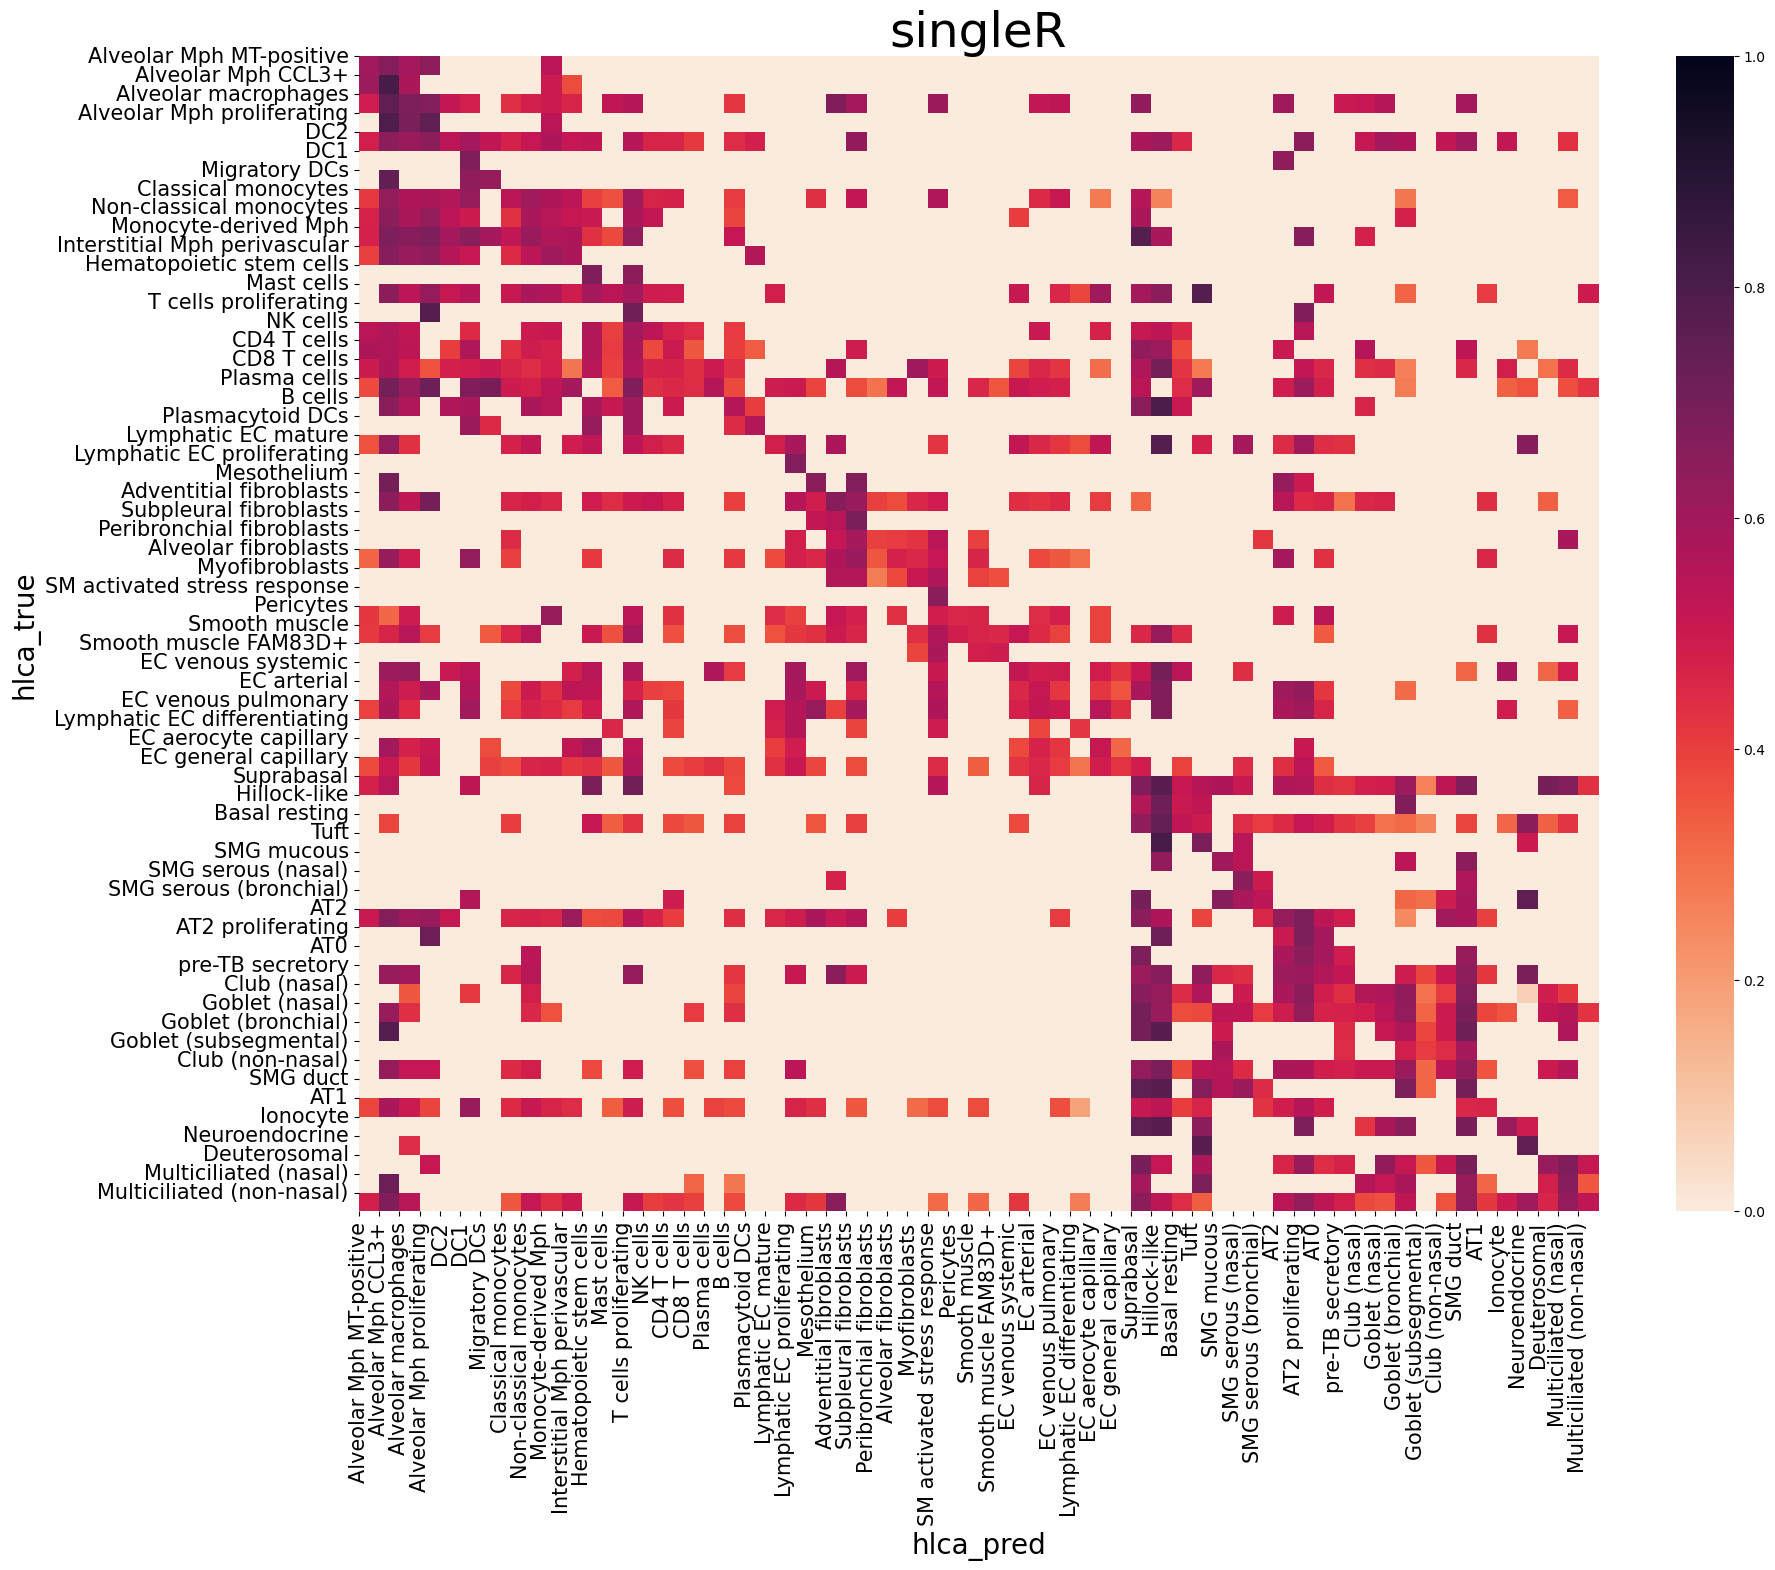

In [9]:
heatmap(sr, 'singleR')

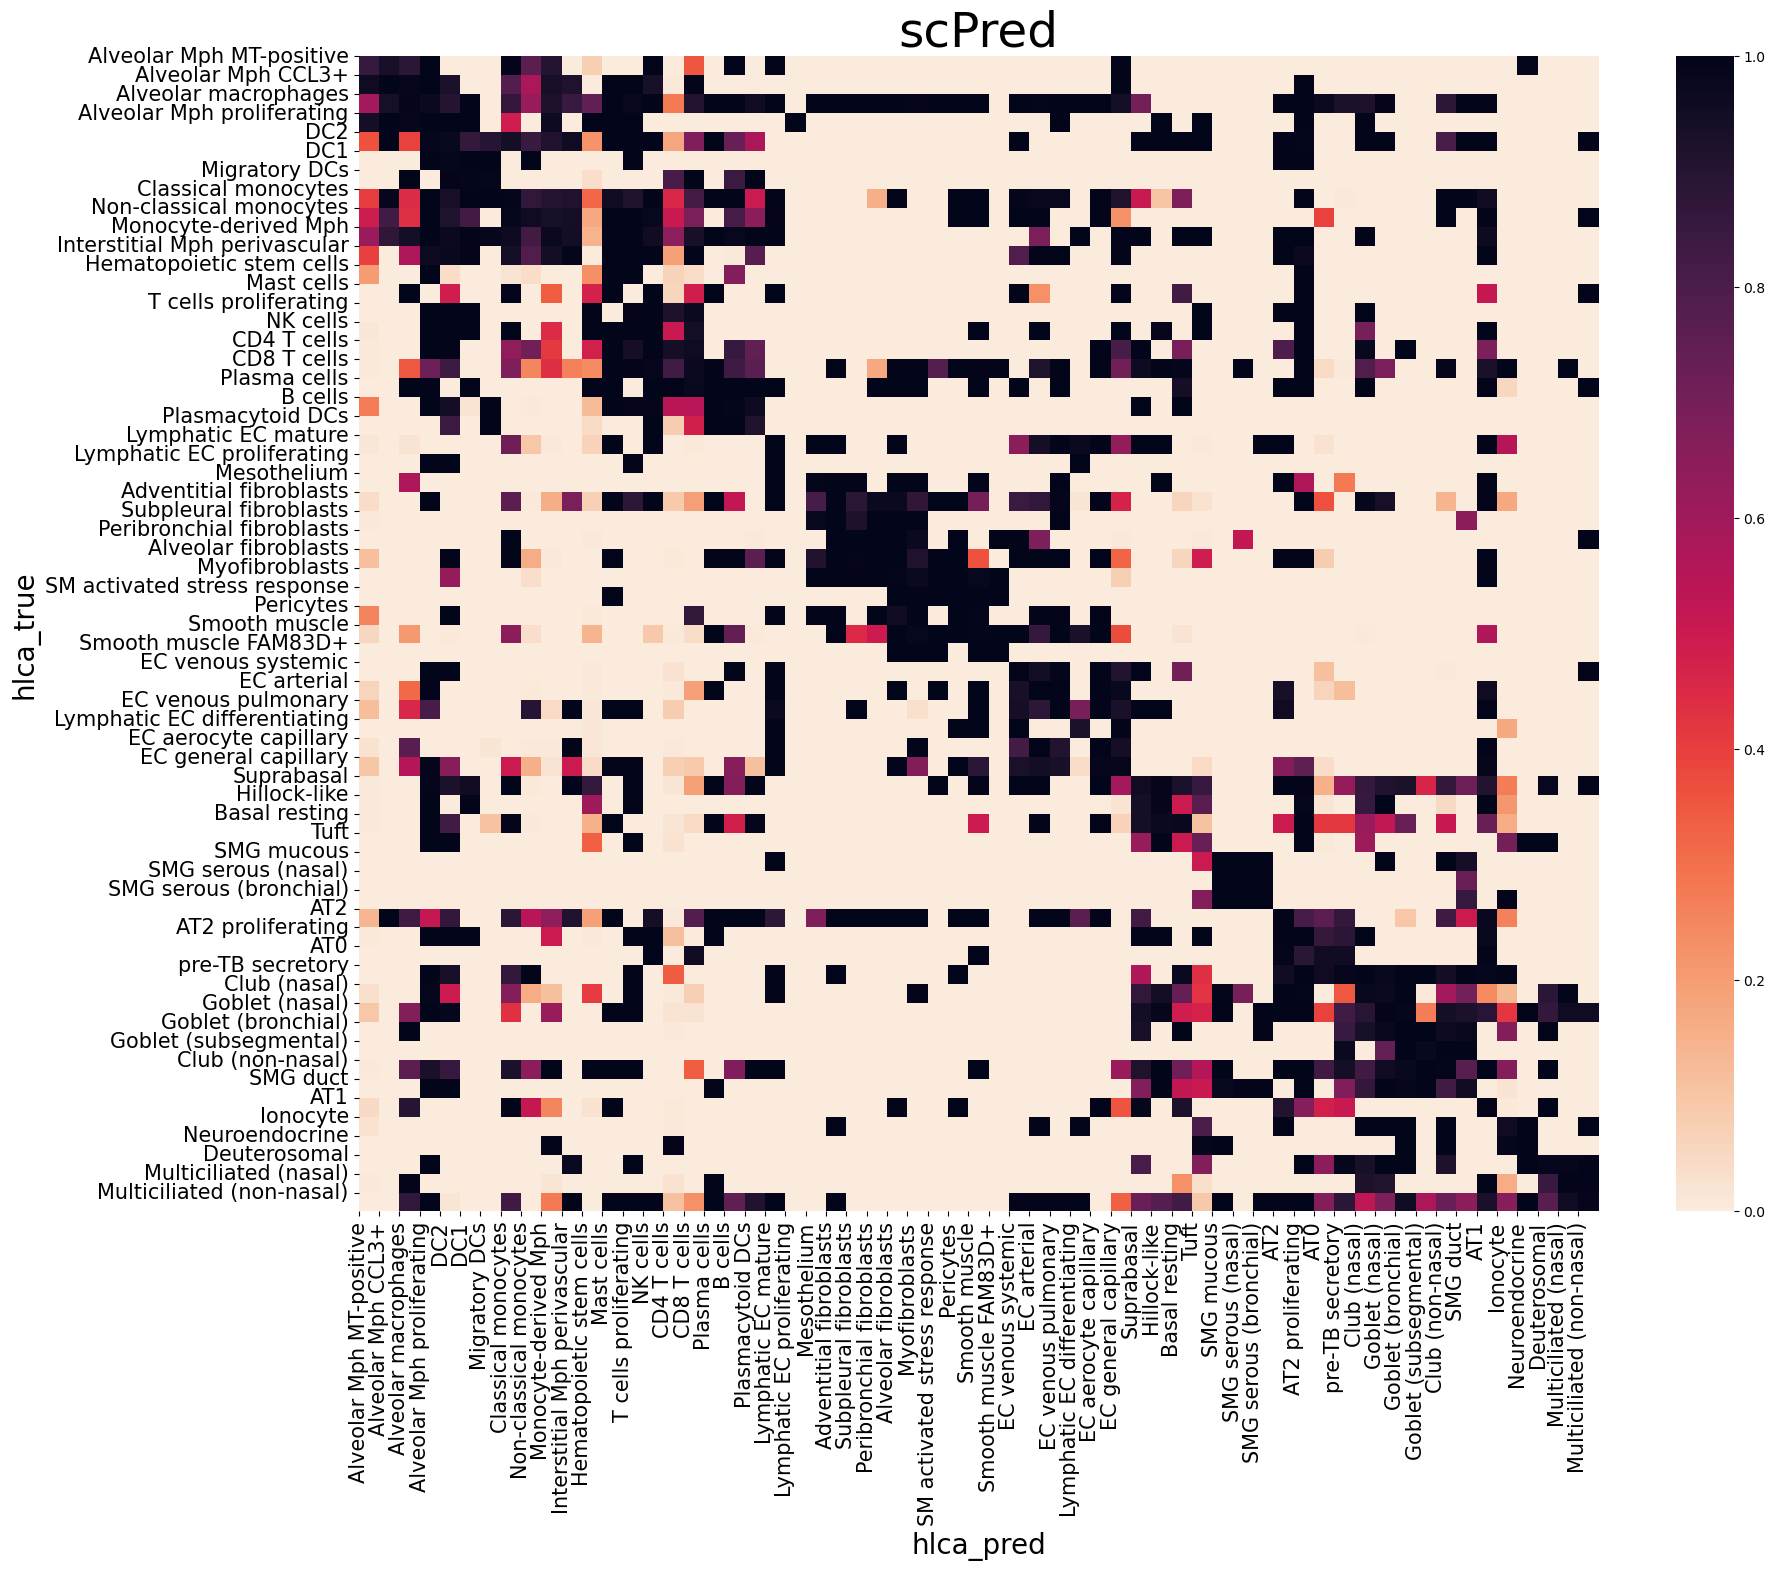

In [10]:
heatmap(sp, 'scPred')